In [1]:
import sys
sys.path.append("../../mymodule")
from backprojection import *
#from plot_backprojection_root import *
import numpy as np

In [2]:
file_path = "/Users/takashima/work/grams/nanograms-analysis/run11/products/Na22/compton.root"
spread_arm=np.deg2rad(3)

dataDict = read_cetree_backprojection_data(
    file_path,
    tree_name="cetree",
    cut="num_hits==2",
)

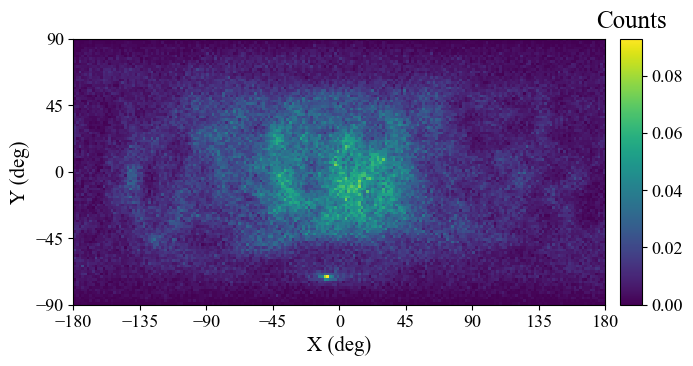

In [4]:
image_center_lat = 0
image_center_lon = 0
image_yaxis_lat  = 90
image_yaxis_lon  = 0
lonlat_kwargs = dict({"xRange": (-180,180), "yRange": (-90,90), "numBinsX": 200, "numBinsY": 100, 
                      "title": " ", "xlabel": "X (deg)", "ylabel": "Y (deg)", 
                      "xticks": np.arange(-180,181,45), "yticks": np.arange(-90,91,45),
                     "figName": "fig/back_projection_sky_deg.pdf", "colorbar_label": "Counts"},)

lonlat = plot_lonlat_backprojection(
    dataDict,
    image_center_lat,
    image_center_lon,
    image_yaxis_lat,
    image_yaxis_lon,
    spread_arm,
    **lonlat_kwargs,
)

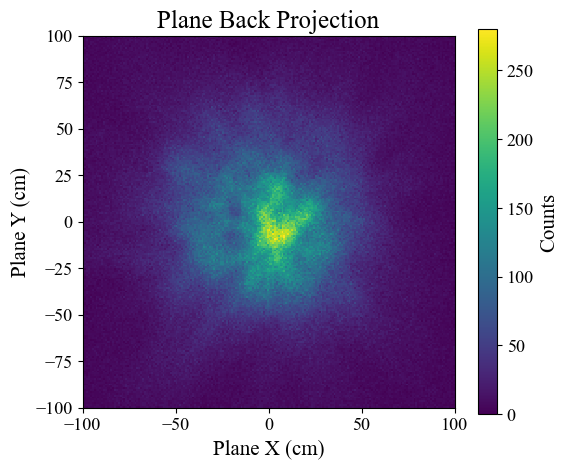

In [5]:
plane_kwargs = {"xRange": (-100, 100), "yRange": (-100, 100), "numBinsX": 200, "numBinsY": 200, "return_hist": False}
plane_point  = np.array([50, 0, 0])
plane_normal = np.array([1, 0, 0])
plane_yaxis  = np.array([0, 0, 1])

plane = plot_plane_backprojection(
    dataDict,
    plane_point,
    plane_normal,
    plane_yaxis,
    spread_arm,
    **plane_kwargs,
)

/Users/takashima/.pyenv/versions/3.12.12/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/Users/takashima/.config', but the default location, /Users/takashima/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


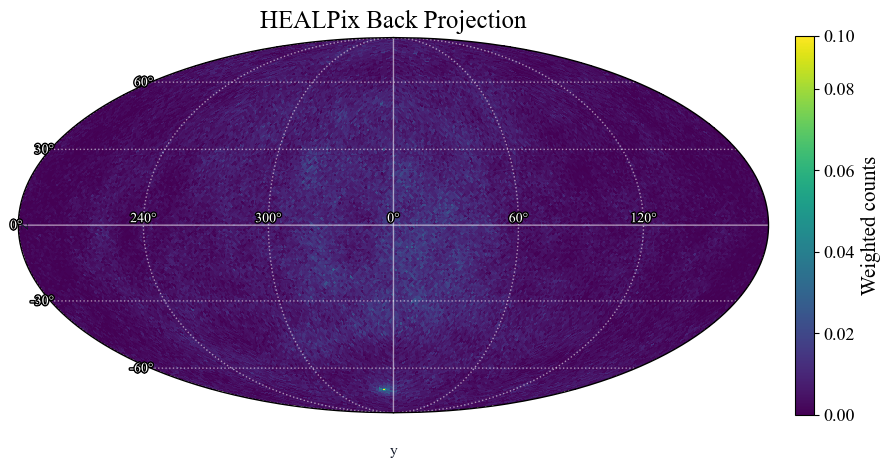

In [6]:
healpix_kwargs = dict({})
healpix = plot_healpix_backprojection_mollweide(
    dataDict,
    spread_arm,
    **healpix_kwargs,
)